In [492]:
import os
import farsight as fs
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import synth_reader as sr
from astropy.io import fits
from astropy.table import Table
from joblib import Parallel, delayed

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.mixture import GaussianMixture
from matplotlib.patches import Ellipse
from astropy.table import join

### Creacion del .fits y carga de datos.

In [2]:
DF_original = pd.read_csv('~/HIIGalaxies/Spectral_synthesis/HIIGsample_stats.csv')


new_cols = ['STARLIGHT','FADO','LAMBDA_N','CHI2','ADEV','A_V','A_NEB','V_STAR','S_STAR',
            'MEAN_LGTL','MEAN_LGTM','MEAN_ZL','MEAN_ZM','MIT','MCT','LG_MIT','LG_MCT','SFR',
            'SSFR','RED_LAW','BASE_SRC','N_BASE']

# 3. Creamos las nuevas columnas vacías con MultiIndex
# Usamos un diccionario de tuplas para que Pandas entienda la jerarquía
for main in new_cols:
    DF_original[main] = None

#DF.loc[0, "sSFR"] = 3



In [3]:
class Results_reader:
    def __init__(self,home,data_frame,software,law_key): # Input file name & file directory and distance in Mpc o z
        self.home = home
        self.data_frame = data_frame
        self.software = software
        self.law_key = law_key

    def get_individual_data(self,idx = '', dist = None):
        if self.software == 'FADO':
            spec = fs.Fado(home = self.home,
                        file = idx,
                        distance = dist)
        if self.software == 'STARLIGHT':
            spec = fs.Starlight(home = self.home,
                        file = idx,
                        distance = dist)
        
        data = {'CHI2':      [  spec.metadata['chi2']                , r'$\mathbfit{\chi^2 / \nu}$'               ], 
                'ADEV':      [  spec.metadata['adev']                , r'$\mathbfit{Adev}$'                       ],
                'A_V':       [  spec.metadata['A_V']                 , r'$\mathbfit{A_{V\star}}$'                 ],
                'A_NEB':     [  spec.metadata['A_Neb']               , r'$\mathbfit{A_{V Neb}}$'                  ],
                'V_STAR':    [  spec.metadata['v_star']              , r'$\mathbfit{v {\star}}$'                  ],
                'S_STAR':    [  spec.metadata['s_star']              , r'$\mathbfit{\sigma {\star}}$'             ],
                'MEAN_LGTL': [  spec.metadata['mean_logt_L']         , r'$\mathbfit{\langle log\,t \rangle_L}$'   ],
                'MEAN_LGTM': [  spec.metadata['mean_logt_M']         , r'$\mathbfit{\langle log\,t \rangle_M}$'   ],
                'MEAN_ZL':   [  spec.metadata['mean_Z_L']            , r'$\mathbfit{\langle Z \rangle_L}$'        ], 
                'MEAN_ZM':   [  spec.metadata['mean_Z_M']            , r'$\mathbfit{\langle Z \rangle_M}$'        ],
                'MIT':       [  spec.metadata['minitot']             , r'$\mathbfit{MassINItotal}$'               ],
                'MCT':       [  spec.metadata['mcortot']             , r'$\mathbfit{MassCORtotal}$'               ],
                'LG_MIT':    [  spec.distance_derived['log_mitot']   , r'$\mathbfit{lgMassINItotal}$'             ],  
                'LG_MCT':    [  spec.distance_derived['log_mctot']   , r'$\mathbfit{lgMassCORtotal}$'             ],
                'SFR':       [  spec.distance_derived['sfr_0']       , r'$\mathbfit{SFR}$'                        ],
                'SSFR':      [  spec.distance_derived['ssfr_0']      , r'$\mathbfit{sSFR}$'                       ],
                'RED_LAW':   [  spec.metadata['red_law']             , r'$\mathbfit{Reddening \, law}$'           ],
                'BASE_SRC':  [  spec.metadata['base_src']            , r'$\mathbfit{Base \, source}$'             ],
                'N_BASE':    [  spec.metadata['n_base']              , r'$\mathbfit{N \, base}$'                  ],
                'LAMBDA_N':  [  spec.metadata['lambda_norm']         , r'$\mathbfit{\lambda (\AA)}$'              ]
                }
        
        return data


        

    def get_bulk_data(self):
        _cols = ['LAMBDA_N','CHI2','ADEV','A_V','A_NEB','V_STAR','S_STAR',
                 'MEAN_LGTL','MEAN_LGTM','MEAN_ZL','MEAN_ZM','MIT','MCT','LG_MIT','LG_MCT','SFR',
                 'SSFR','RED_LAW','BASE_SRC','N_BASE']
        path = self.home
        if self.software == 'FADO':
            spec_list = [f for f in os.listdir(path) if f.endswith('_1D.fits')]
            spec_list.sort()
        if self.software == 'STARLIGHT':
            spec_list = [f for f in os.listdir(path) if f.endswith('.out')]
            spec_list.sort()
        spec_list = [item for item in spec_list if self.law_key in item]
        DF = self.data_frame.copy()
        for file_name in spec_list:
            idx_val = int(file_name[0:3])
            mask = DF['TAB5_INDEX'] == idx_val
            z = DF.loc[mask, 'Z'].iloc[0]
            results = self.get_individual_data(idx = file_name, dist = z)
            DF.loc[mask, "FADO"] = (self.software == 'FADO')
            DF.loc[mask, "STARLIGHT"] = (self.software == 'STARLIGHT')
            for lbl in _cols:
                DF.loc[mask, lbl] = results[lbl][0]
        return DF
                

In [4]:
FD_CAL_4020 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/FADO/output_4020/',DF_original,'FADO','CALR').get_bulk_data()
FD_GD1_4020 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/FADO/output_4020/',DF_original,'FADO','GOR1').get_bulk_data()
FD_GD2_4020 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/FADO/output_4020/',DF_original,'FADO','GOR2').get_bulk_data()
FD_GD3_4020 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/FADO/output_4020/',DF_original,'FADO','GOR3').get_bulk_data()
print('Done')

FD_CAL_5100 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/FADO/output_5100/',DF_original,'FADO','CALR').get_bulk_data()
FD_GD1_5100 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/FADO/output_5100/',DF_original,'FADO','GOR1').get_bulk_data()
FD_GD2_5100 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/FADO/output_5100/',DF_original,'FADO','GOR2').get_bulk_data()
FD_GD3_5100 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/FADO/output_5100/',DF_original,'FADO','GOR3').get_bulk_data()
print('Done')

FD_CAL_4150 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/FADO/output_4150/',DF_original,'FADO','CALR').get_bulk_data()
FD_GD1_4150 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/FADO/output_4150/',DF_original,'FADO','GOR1').get_bulk_data()
FD_GD2_4150 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/FADO/output_4150/',DF_original,'FADO','GOR2').get_bulk_data()
FD_GD3_4150 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/FADO/output_4150/',DF_original,'FADO','GOR3').get_bulk_data()
print('Done')

SL_CAL_4020 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/STARLIGHT/output_4020/',DF_original,'STARLIGHT','CAL').get_bulk_data()
SL_GD1_4020 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/STARLIGHT/output_4020/',DF_original,'STARLIGHT','GD1').get_bulk_data()
SL_GD2_4020 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/STARLIGHT/output_4020/',DF_original,'STARLIGHT','GD2').get_bulk_data()
SL_GD3_4020 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/STARLIGHT/output_4020/',DF_original,'STARLIGHT','GD3').get_bulk_data()
print('Done')

SL_CAL_5100 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/STARLIGHT/output_5100/',DF_original,'STARLIGHT','CAL').get_bulk_data()
SL_GD1_5100 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/STARLIGHT/output_5100/',DF_original,'STARLIGHT','GD1').get_bulk_data()
SL_GD2_5100 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/STARLIGHT/output_5100/',DF_original,'STARLIGHT','GD2').get_bulk_data()
SL_GD3_5100 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/STARLIGHT/output_5100/',DF_original,'STARLIGHT','GD3').get_bulk_data()
print('Done')

SL_CAL_4150 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/STARLIGHT/output_4150/',DF_original,'STARLIGHT','CAL').get_bulk_data()
SL_GD1_4150 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/STARLIGHT/output_4150/',DF_original,'STARLIGHT','GD1').get_bulk_data()
SL_GD2_4150 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/STARLIGHT/output_4150/',DF_original,'STARLIGHT','GD2').get_bulk_data()
SL_GD3_4150 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/STARLIGHT/output_4150/',DF_original,'STARLIGHT','GD3').get_bulk_data()
print('Done')

#s_srCAL_4020 = SL_CAL_4020[SL_CAL_4020['TAB5_INDEX']!=56]
#f_srCAL_4020 = FD_CAL_4020[FD_CAL_4020['TAB5_INDEX']!=56]
#s_srGD1_4020 = SL_GD1_4020[SL_GD1_4020['TAB5_INDEX']!=56]
#f_srGD1_4020 = FD_GD1_4020[FD_GD1_4020['TAB5_INDEX']!=56]
#s_srGD2_4020 = SL_GD2_4020[SL_GD2_4020['TAB5_INDEX']!=56]
#f_srGD2_4020 = FD_GD2_4020[FD_GD2_4020['TAB5_INDEX']!=56]
#s_srGD3_4020 = SL_GD3_4020[SL_GD3_4020['TAB5_INDEX']!=56]
#f_srGD3_4020 = FD_GD3_4020[FD_GD3_4020['TAB5_INDEX']!=56]

Done
Done
Done
Done
Done
Done


In [5]:
SL_CAL_4020['RED_LAW'] = np.unique(FD_CAL_4020['RED_LAW'])[0]
SL_CAL_5100['RED_LAW'] = np.unique(FD_CAL_5100['RED_LAW'])[0]
SL_CAL_4150['RED_LAW'] = np.unique(FD_CAL_4150['RED_LAW'])[0]

SL_GD1_4020['RED_LAW'] = np.unique(FD_GD1_4020['RED_LAW'])[0]
SL_GD1_5100['RED_LAW'] = np.unique(FD_GD1_5100['RED_LAW'])[0]
SL_GD1_4150['RED_LAW'] = np.unique(FD_GD1_4150['RED_LAW'])[0]

SL_GD2_4020['RED_LAW'] = np.unique(FD_GD2_4020['RED_LAW'])[0]
SL_GD2_5100['RED_LAW'] = np.unique(FD_GD2_5100['RED_LAW'])[0]
SL_GD2_4150['RED_LAW'] = np.unique(FD_GD2_4150['RED_LAW'])[0]

SL_GD3_4020['RED_LAW'] = np.unique(FD_GD3_4020['RED_LAW'])[0]
SL_GD3_5100['RED_LAW'] = np.unique(FD_GD3_5100['RED_LAW'])[0]
SL_GD3_4150['RED_LAW'] = np.unique(FD_GD3_4150['RED_LAW'])[0]

In [6]:
DF_stacked = pd.concat([FD_CAL_4020, FD_CAL_5100,FD_CAL_4150, 
                        FD_GD1_4020, FD_GD1_5100,FD_GD1_4150,
                        FD_GD2_4020, FD_GD2_5100,FD_GD2_4150,
                        FD_GD3_4020, FD_GD3_5100,FD_GD3_4150,
                        SL_CAL_4020, SL_CAL_5100,SL_CAL_4150, 
                        SL_GD1_4020, SL_GD1_5100,SL_GD1_4150,
                        SL_GD2_4020, SL_GD2_5100,SL_GD2_4150,
                        SL_GD3_4020, SL_GD3_5100,SL_GD3_4150,
                        ], axis=0, ignore_index=True)

DF_stacked['A_NEB'] = pd.to_numeric(DF_stacked['A_NEB'], errors='coerce')
DF_stacked['MEAN_LGTL'] = DF_stacked['MEAN_LGTL'].astype('float64')
DF_stacked['MEAN_LGTM'] = DF_stacked['MEAN_LGTM'].astype('float64')
DF_stacked['MIT'] = DF_stacked['MIT'].astype('float64')
DF_stacked['MCT'] = DF_stacked['MCT'].astype('float64')

for col in DF_stacked.columns:
    if DF_stacked[col].dtype == 'object':
        try:
            temp_numeric = pd.to_numeric(DF_stacked[col], errors='raise')
            DF_stacked[col] = temp_numeric
        except (ValueError, TypeError):
            DF_stacked[col] = DF_stacked[col].astype(str)
            DF_stacked[col] = DF_stacked[col].replace(['None', 'nan', 'NaN'], '')

Final_table = Table.from_pandas(DF_stacked)

In [7]:
fits_name = 'Synthesis_runs.fits'
rands_x1hdu = np.random.random((1,1))
primary_hdu = fits.PrimaryHDU(data=rands_x1hdu)
HDU = fits.HDUList([primary_hdu])
lista_HDUs = [primary_hdu]
HDU_final = fits.HDUList(lista_HDUs)
HDU_final.writeto(fits_name, overwrite=True)
HDR = fits.Header()
HDR.insert(0,('TABLE', 'CONCATENATED', 'Concatenaded Table of Starlight and Fado Results'))
HDR.insert(1, ('COMMENT','121 spectra. 4 extintion laws and 3 lambda norm'))
hdu = fits.BinTableHDU(data = Final_table,header = HDR, name = 'Synthesis')
lista_HDUs.append(hdu)
HDU_final = fits.HDUList([primary_hdu,hdu])
HDU_final.writeto(fits_name, overwrite=True)

### Visualizacion de resultados

In [205]:
class Data_get:
    def __init__(self,data,outliers,select):
        self.data = data
        self.outliers = outliers
        self.data_clean = None
        self.select = select #Debe ser una lista de Tuplas
        self.set = None
        self.remove_outliers()
        self.set_selection()


    def remove_outliers(self):
        tmp_dataFrame = self.data
        for x in self.outliers:
            tmp_dataFrame = tmp_dataFrame[tmp_dataFrame['TAB5_INDEX']!=x]
        self.data_clean = tmp_dataFrame 

    def set_selection(self):
        tmp_dataFrame = self.data_clean
        for s in range(len(self.select)):
            if self.select[s][1] == '==':
                tmp_dataFrame = tmp_dataFrame[tmp_dataFrame[self.select[s][0]]==self.select[s][2]]
            elif self.select[s][1] == '!=':
                tmp_dataFrame = tmp_dataFrame[tmp_dataFrame[self.select[s][0]]!=self.select[s][2]]
            elif self.select[s][1] == '>=':
                tmp_dataFrame = tmp_dataFrame[tmp_dataFrame[self.select[s][0]]>=self.select[s][2]]
            elif self.select[s][1] == '<=':
                tmp_dataFrame = tmp_dataFrame[tmp_dataFrame[self.select[s][0]]<=self.select[s][2]]
            elif self.select[s][1] == '>':
                tmp_dataFrame = tmp_dataFrame[tmp_dataFrame[self.select[s][0]]>self.select[s][2]]
            elif self.select[s][1] == '<':
                tmp_dataFrame = tmp_dataFrame[tmp_dataFrame[self.select[s][0]]<self.select[s][2]]
        self.set = tmp_dataFrame

    def figure_merit(self):
        x = np.array(self.set['ADEV'])
        y = np.array(self.set['CHI2'])
        punto_ref = np.array([0, 1])
        distancias = np.sqrt((x - punto_ref[0])**2 + (y - punto_ref[1])**2)
        distancia_promedio = np.mean(distancias)

        return distancia_promedio


        
class Plotter(Data_get):
    def __init__(self,data,outliers,select):
        super().__init__(data,outliers,select)
        self.remove_outliers()
        self.set_selection()


In [206]:
Final_table = Table.read(fits.open('Synthesis_runs.fits')[1])

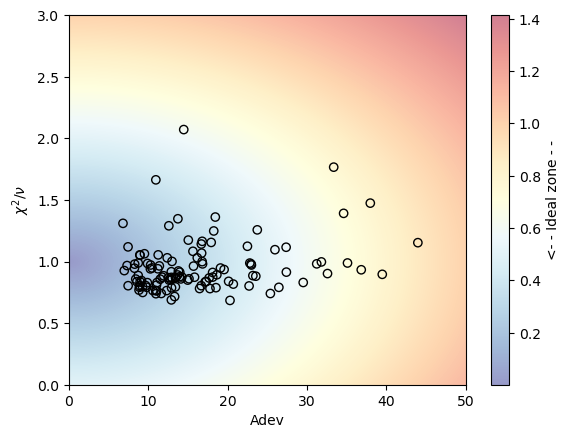

In [552]:
# 1. Crear la malla con tus rangos específicos
x = np.linspace(0, 50, 500)
y = np.linspace(0, 3, 500)
X, Y = np.meshgrid(x, y)

# 2. Normalizar las distancias para que X e Y pesen lo mismo
# Escalamos X (0 a 50) para que actúe como (0 a 1)
# Escalamos Y (0 a 3) para que actúe como (0 a 1)
x_norm = (X - 0) / 50
y_norm = (Y - 1) / 2  # Distancia relativa al punto 1 en un rango de 3

# 3. Calcular la distancia combinada usando los valores normalizados
Z = np.sqrt(x_norm**2 + y_norm**2)

# 4. Graficar
fig, ax = plt.subplots()
im = ax.imshow(Z, extent=[0, 50, 0, 3], origin='lower', cmap='RdYlBu_r', aspect='auto',alpha=0.5)

fd_g3 = Data_get(Final_table,[56],
                            [('LAMBDA_N','==',4020),
                            ('SDSS_SNR','>=',10),
                            ('RED_LAW','==','Gordon et al. 2003 - SMC Bar'),
                            ('FADO','==',True)]).set

sl_g3 = Data_get(Final_table,[56],
                            [('LAMBDA_N','==',4020),
                            ('SDSS_SNR','>=',10),
                            ('RED_LAW','==','Gordon et al. 2003 - SMC Bar'),
                            ('STARLIGHT','==',True)]).set

fd_hq = Data_get(Final_table,[56],
                            [('SDSS_SNR','>=',10),('LAMBDA_N','==',4020),
                            ('RED_LAW','==','Gordon et al. 2003 - SMC Bar'),
                            ('FADO','==',True),
                            ('ADEV','>=',0),('ADEV','<=',25),
                            ('CHI2','>=',0.7),('CHI2','<=',1.3)]).set


sl_hq = Data_get(Final_table,[56],
                            [('SDSS_SNR','>=',10),('LAMBDA_N','==',4020),
                            ('RED_LAW','==','Gordon et al. 2003 - SMC Bar'),
                            ('STARLIGHT','==',True),
                            ('ADEV','>=',0),('ADEV','<=',25),
                            ('CHI2','>=',0.7),('CHI2','<=',1.3)]).set


sample = Data_get(Final_table,[56],
                            [('FADO','==',True),
                            ('LAMBDA_N','==',4020),
                            ('RED_LAW','==','Gordon et al. 2003 - SMC Bar')]).set
                            #('FADO','==',True),#]).set
                            #('ADEV','>=',0),('ADEV','<=',25),
                            #('CHI2','>=',0.7),('CHI2','<=',1.3)]).set



#ax.scatter(fd_g3['ADEV'],
#           fd_g3['CHI2'],
#           marker = 'o',facecolors='none', edgecolors='purple')
ax.scatter(sample['ADEV'],
           sample['CHI2'],
           marker = 'o',facecolors='none', edgecolors='black')


# 5. Estética
#ax.set_title('Mapa de Calor Equilibrado (Objetivo X=0, Y=1)')
ax.set_xlabel(r'Adev')
ax.set_ylabel(r'$\chi^{2}/\nu$')
plt.colorbar(im, label='<- - Ideal zone - -')

# Opcional: Dibujar un punto en el objetivo para verificar
#ax.plot(0, 1, 'ko', markersize=10, label='Objetivo (0,1)') 

plt.show()

In [548]:
sample1 = Data_get(Final_table,[56],
                            [('STARLIGHT','==',True),('SDSS_SNR','>=',10),
                            ('ADEV','>=',0),('ADEV','<=',25),
                            ('CHI2','>=',0.7),('CHI2','<=',1.3)]).set

sample2 = Data_get(Final_table,[56],
                            [('FADO','==',True),('SDSS_SNR','>=',10),
                            ('ADEV','>=',0),('ADEV','<=',25),
                            ('CHI2','>=',0.7),('CHI2','<=',1.3)]).set

(array([ 18., 127., 122.,  65.,  47.,  99.,  66.,  35.,  43., 262.]),
 array([ 6.25937176,  6.65391617,  7.04846058,  7.44300499,  7.8375494 ,
         8.23209381,  8.62663822,  9.02118263,  9.41572704,  9.81027145,
        10.20481586]),
 <BarContainer object of 10 artists>)

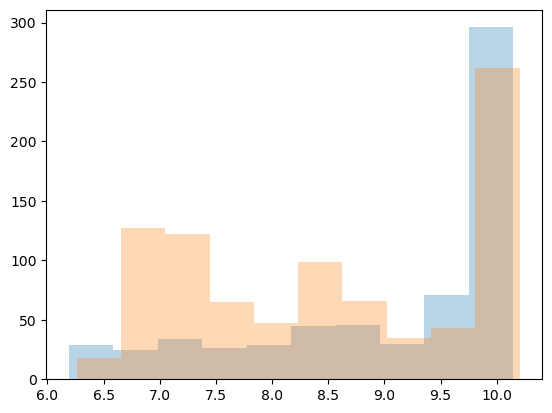

In [550]:
plt.hist(sample1['MEAN_LGTM'],alpha=0.3)
plt.hist(sample2['MEAN_LGTM'],alpha=0.3)

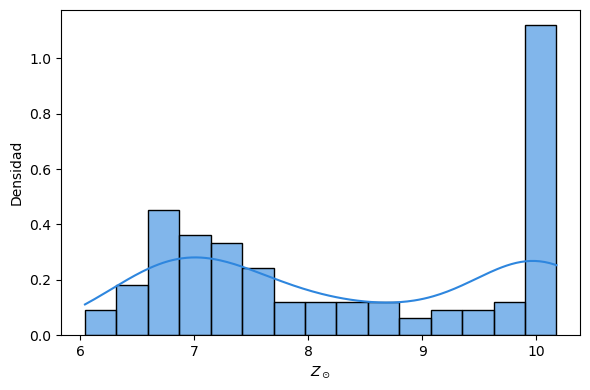

In [553]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(6,4))

Z = np.array(sample['MEAN_LGTM']).byteswap().newbyteorder()


sns.histplot(
    Z,
    bins=15,
    kde=True,
    stat="density",
    color="#2E86DE",
    edgecolor="black",
    alpha=0.6,
    ax=ax
)

ax.set_xlabel(r'$Z_\odot$')
ax.set_ylabel('Densidad')

plt.tight_layout()
plt.show()

In [251]:
P = Data_get(Final_table,[56],[('LAMBDA_N','==',4020),('SDSS_SNR','>=',10),('RED_LAW','==','Gordon et al. 2003 - SMC Bar')]).figure_merit()

ext_laws = np.unique(Final_table['RED_LAW'])
L_norm = np.unique(Final_table['LAMBDA_N'])

starlight_merits = []
fado_merits = []
aux = [0,1,2,3]

for K in range(0,3):
    for k in range(len(aux)):
        starlight_merits.append(Data_get(Final_table,[56],
                            [('LAMBDA_N','==',L_norm[K]),
                            ('SDSS_SNR','>=',10),
                            ('RED_LAW','==',ext_laws[k]),
                            ('STARLIGHT','==',True)]).figure_merit())
        fado_merits.append(Data_get(Final_table,[56],
                            [('LAMBDA_N','==',L_norm[K]),
                            ('SDSS_SNR','>=',10),
                            ('RED_LAW','==',ext_laws[k]),
                            ('FADO','==',True)]).figure_merit())

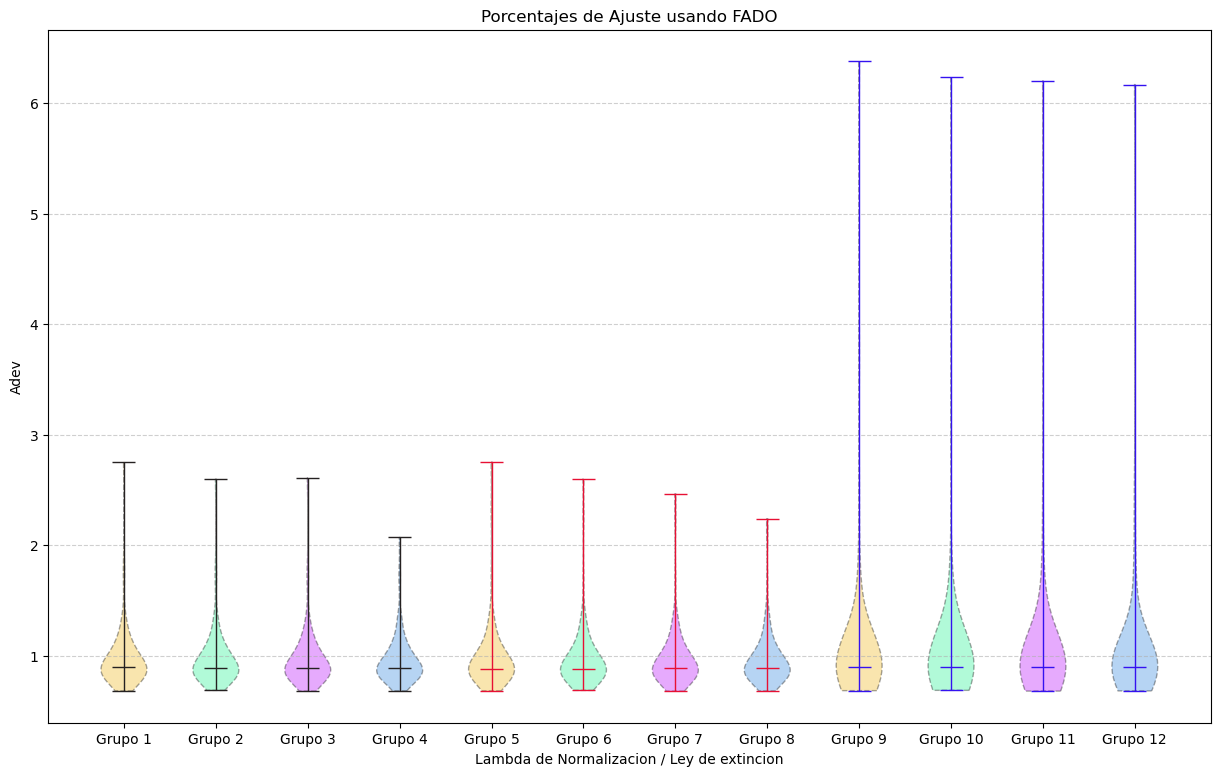

In [115]:
fig, ax = plt.subplots(figsize=(15, 9))

ext_laws = np.unique(Final_table['RED_LAW'])
L_norm = np.unique(Final_table['LAMBDA_N'])

aux = [0,1,2,3]

data = []

for K in range(0,3):
    for k in range(len(aux)):
        #print(L_norm[K],ext_laws[k])
        data.append(Data_get(Final_table,[56],
                            [('LAMBDA_N','==',L_norm[K]),
                            ('SDSS_SNR','>=',10),
                            ('RED_LAW','==',ext_laws[k]),
                            ('FADO','==',True)]).set['CHI2'])
        
parts = ax.violinplot(data, showmeans=False, showmedians=True)


law_colors = [
    "#EEB517",
    "#21F391",
    "#B80DFC",
    "#2E86DE"
]

for idx, body in enumerate(parts['bodies']):
    
    j = idx % len(ext_laws)   # índice de la ley de extinción: 0,1,2,3
    
    body.set_facecolor(law_colors[j])
    body.set_edgecolor('black')
    body.set_alpha(0.35)
    body.set_linestyle('--')

ln_col = ["#252121","#E71034", "#3412F0" ]

n_laws = len(ext_laws)   # 4
n_lambdas = len(L_norm)  # 3

median_colors = [
    ln_col[idx // len(ext_laws)]
    for idx in range(len(data))
]

parts['cbars'].set_color(median_colors)
parts['cbars'].set_linewidth(1.0)
parts['cmaxes'].set_color(median_colors)
parts['cmaxes'].set_linewidth(1.0)
parts['cmins'].set_color(median_colors)
parts['cmins'].set_linewidth(1.0)
parts['cmedians'].set_color(median_colors)
parts['cmedians'].set_linewidth(1.0)

ax.set_xticks(range(1, 13))
ax.set_xticklabels([f'Grupo {i}' for i in range(1, 13)])
ax.set_title('Porcentajes de Ajuste usando FADO')
ax.set_xlabel('Lambda de Normalizacion / Ley de extincion')
ax.set_ylabel('Adev')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [322]:

var = sample['MEAN_LGTM']
# ===== INPUT =====
V = np.asarray(var).astype(float)   # tu variable

# ===== limpieza =====
mask = np.isfinite(V)
V = V[mask]

# reshape para sklearn
X = V.reshape(-1, 1)

k = 2

kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
labels = kmeans.fit_predict(X)

centers = np.sort(kmeans.cluster_centers_.flatten())

print("Centros:", centers)

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7009189d31a0>
Traceback (most recent call last):
  File "/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^

Centros: [7.10155063 9.74887013]


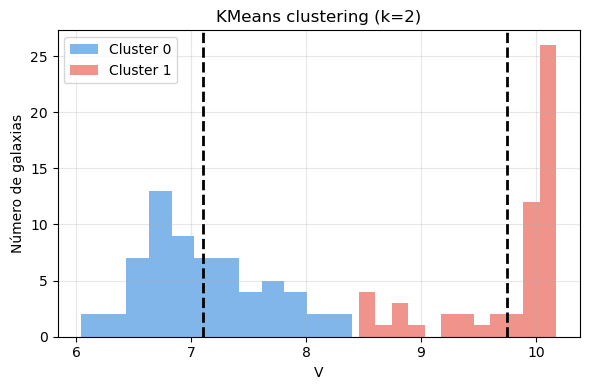

In [323]:
fig, ax = plt.subplots(figsize=(6,4))

colors = ['#2E86DE', '#E74C3C']

for i in range(k):
    ax.hist(
        V[labels == i],
        bins=12,
        alpha=0.6,
        color=colors[i],
        label=f'Cluster {i}'
    )

# centros
for c in centers:
    ax.axvline(c, linestyle='--', linewidth=2, color='black')

ax.set_xlabel('V')
ax.set_ylabel('Número de galaxias')
ax.set_title('KMeans clustering (k=2)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

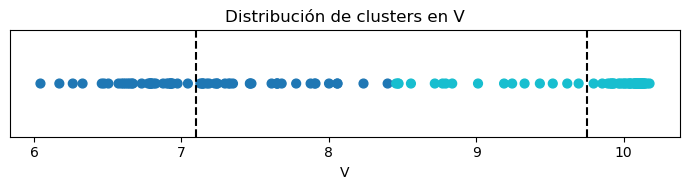

In [324]:
fig, ax = plt.subplots(figsize=(7,2))

y = np.zeros_like(V)

ax.scatter(V, y, c=labels, cmap='tab10', s=40)

for c in centers:
    ax.axvline(c, linestyle='--', color='black')

ax.set_xlabel('V')
ax.set_yticks([])
ax.set_title('Distribución de clusters en V')

plt.tight_layout()
plt.show()

In [325]:
score = silhouette_score(X, labels)
print("Silhouette score:", score)

Silhouette score: 0.7543225570605101


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x70090f2b6480>
Traceback (most recent call last):
  File "/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^

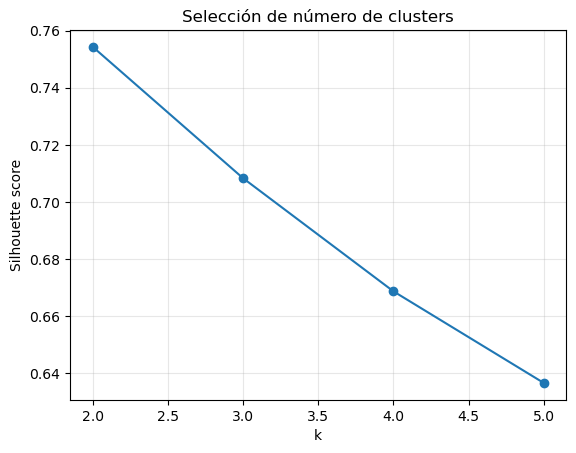

In [326]:
scores = []
ks = range(2,6)

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    lab = km.fit_predict(X)
    score = silhouette_score(X, lab)
    scores.append(score)

plt.plot(ks, scores, 'o-')
plt.xlabel('k')
plt.ylabel('Silhouette score')
plt.title('Selección de número de clusters')
plt.grid(alpha=0.3)

plt.show()

In [327]:
for i in range(2):
    print(f"\nCluster {i}")
    print("N =", len(V[labels==i]))
    print("Mean =", np.mean(V[labels==i]))
    print("Std =", np.std(V[labels==i]))


Cluster 0
N = 64
Mean = 7.101550631225109
Std = 0.5240861734726843

Cluster 1
N = 56
Mean = 9.748870134353638
Std = 0.524805136097978


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x70090f2b7880>
Traceback (most recent call last):
  File "/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^

Medias: [ 7.50233451 10.04768865]
Sigmas: [0.93603996 0.08927095]
Pesos: [0.67209597 0.32790403]


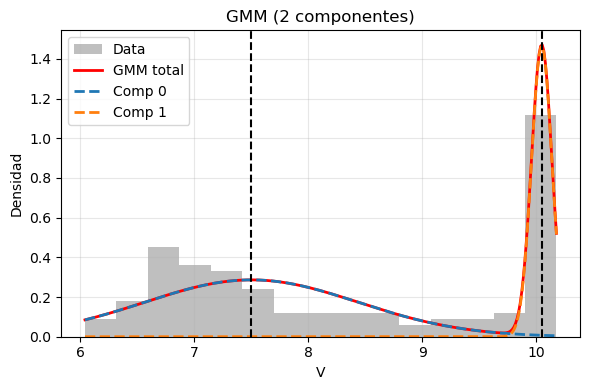

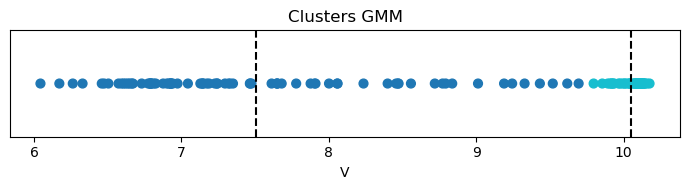

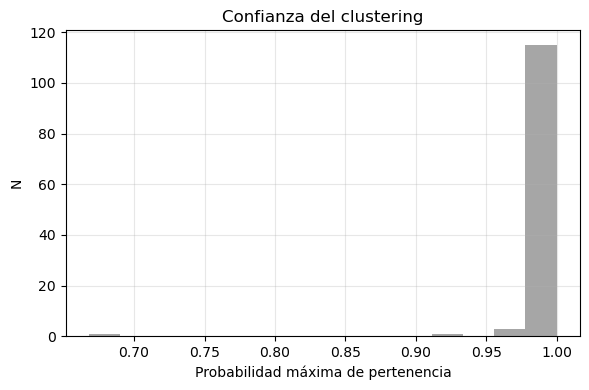

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x700918752700>
Traceback (most recent call last):
  File "/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^

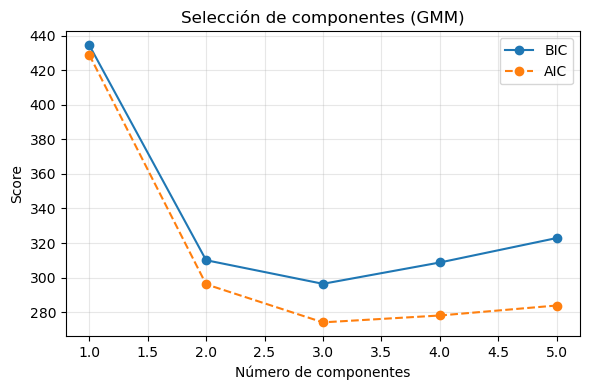


Cluster 0
N = 80
Mean = 7.48272812962532
Std = 0.9141184585584621

Cluster 1
N = 40
Mean = 10.045442938804626
Std = 0.09141050997528036


In [328]:
from sklearn.mixture import GaussianMixture

# ===== INPUT =====
V = np.asarray(var).astype(float)   # <-- cambia aquí tu variable

# ===== limpieza =====
mask = np.isfinite(V)
V = V[mask]

X = V.reshape(-1, 1)

# ===== MODELO =====
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(X)

labels = gmm.predict(X)
proba = gmm.predict_proba(X)

means = gmm.means_.flatten()
stds  = np.sqrt(gmm.covariances_).flatten()
weights = gmm.weights_

print("Medias:", means)
print("Sigmas:", stds)
print("Pesos:", weights)

# ============================================
# 🔷 HISTOGRAMA + PDF del modelo
# ============================================

fig, ax = plt.subplots(figsize=(6,4))

# histograma
ax.hist(V, bins=15, density=True, alpha=0.5, color='gray', label='Data')

# grid para PDF
x = np.linspace(V.min(), V.max(), 300).reshape(-1,1)
pdf = np.exp(gmm.score_samples(x))

ax.plot(x, pdf, 'r-', lw=2, label='GMM total')

# componentes individuales
for i in range(2):
    mu = means[i]
    sigma = stds[i]
    weight = weights[i]
    
    comp = weight * (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu)/sigma)**2)
    ax.plot(x, comp, '--', lw=2, label=f'Comp {i}')

# centros
for m in means:
    ax.axvline(m, linestyle='--', color='black')

ax.set_xlabel('V')
ax.set_ylabel('Densidad')
ax.set_title('GMM (2 componentes)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 🔷 SCATTER 1D (clusters)
# ============================================

fig, ax = plt.subplots(figsize=(7,2))

y = np.zeros_like(V)

ax.scatter(V, y, c=labels, cmap='tab10', s=40)

for m in means:
    ax.axvline(m, linestyle='--', color='black')

ax.set_xlabel('V')
ax.set_yticks([])
ax.set_title('Clusters GMM')

plt.tight_layout()
plt.show()

# ============================================
# 🔷 INCERTIDUMBRE (probabilidad)
# ============================================

fig, ax = plt.subplots(figsize=(6,4))

ax.hist(proba.max(axis=1), bins=15, color='gray', alpha=0.7)

ax.set_xlabel('Probabilidad máxima de pertenencia')
ax.set_ylabel('N')
ax.set_title('Confianza del clustering')

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 🔷 BIC/AIC (selección de número de clusters)
# ============================================

ks = range(1,6)
bics, aics = [], []

for k in ks:
    g = GaussianMixture(n_components=k, random_state=42).fit(X)
    bics.append(g.bic(X))
    aics.append(g.aic(X))

plt.figure(figsize=(6,4))
plt.plot(ks, bics, 'o-', label='BIC')
plt.plot(ks, aics, 'o--', label='AIC')

plt.xlabel('Número de componentes')
plt.ylabel('Score')
plt.legend()
plt.grid(alpha=0.3)
plt.title('Selección de componentes (GMM)')

plt.tight_layout()
plt.show()

# ============================================
# 🔷 RESUMEN POR CLUSTER
# ============================================

for i in range(2):
    subset = V[labels == i]
    print(f"\nCluster {i}")
    print("N =", len(subset))
    print("Mean =", np.mean(subset))
    print("Std =", np.std(subset))

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x700909a88720>
Traceback (most recent call last):
  File "/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^

Medias:
 [[7.32709548 0.673309  ]
 [9.91787154 0.35283504]]
Pesos: [0.70567508 0.29432492]


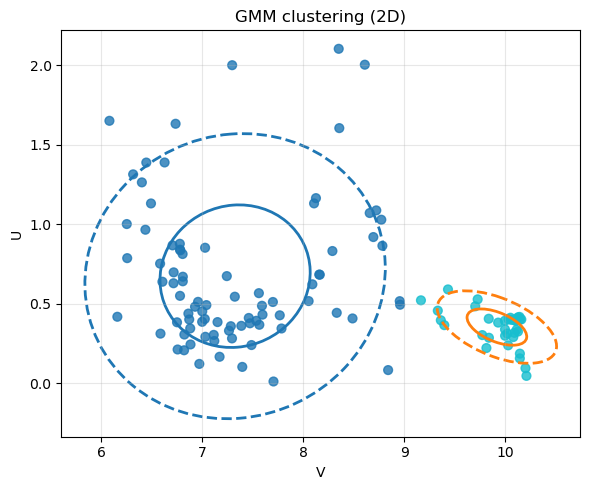

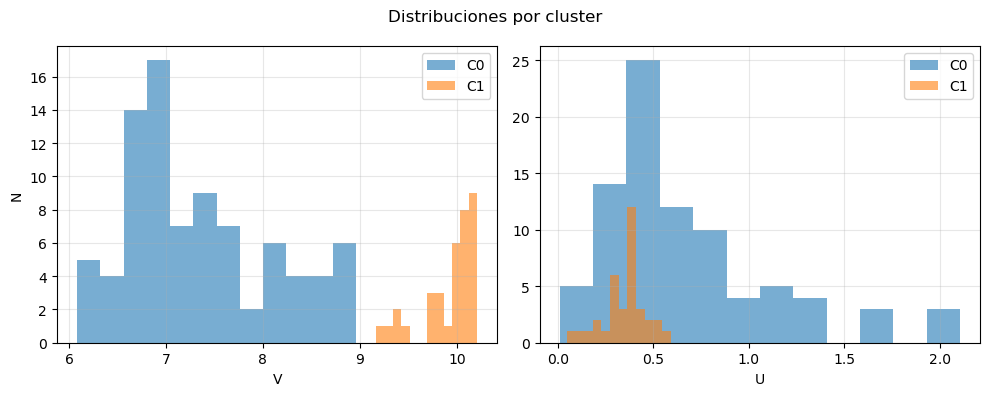

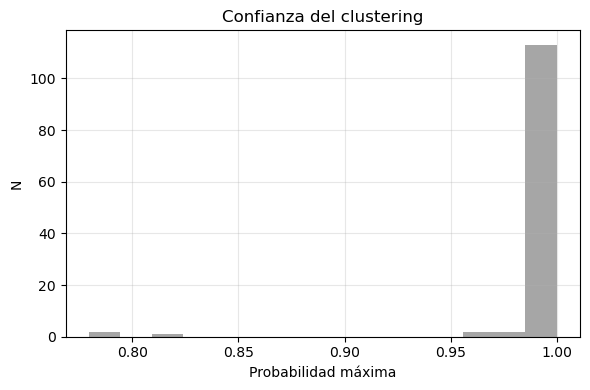

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7009098aba60>
Traceback (most recent call last):
  File "/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^

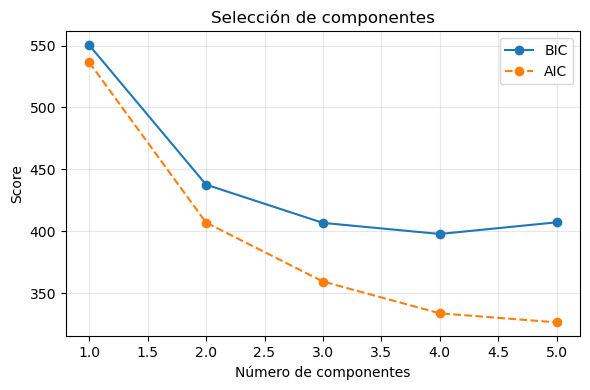


Cluster 0
N = 85
Mean V = 7.332201867945054
Mean U = 0.6727166520809782

Cluster 1
N = 35
Mean V = 9.929082652500698
Mean U = 0.3513528106365443


In [452]:
var1 = sample['MEAN_LGTM']
var2 = sample['MEAN_ZM']


# ===== INPUT =====
V = np.asarray(var1).astype(float)   # <-- variable 1 (ej: edad)
U = np.asarray(var2).astype(float)   # <-- variable 2 (ej: metalicidad)

# ===== limpieza =====
mask = np.isfinite(V) & np.isfinite(U)
V = V[mask]
U = U[mask]

X = np.column_stack([V, U])

# ===== MODELO =====
k = 2
gmm = GaussianMixture(n_components=k, random_state=42)
gmm.fit(X)

labels = gmm.predict(X)
proba  = gmm.predict_proba(X)

means = gmm.means_
covs  = gmm.covariances_
weights = gmm.weights_

print("Medias:\n", means)
print("Pesos:", weights)

# ============================================
# 🔷 SCATTER con clusters
# ============================================

fig, ax = plt.subplots(figsize=(6,5))

sc = ax.scatter(V, U, c=labels, cmap='tab10', s=40, alpha=0.8)

ax.set_xlabel('V')
ax.set_ylabel('U')
ax.set_title('GMM clustering (2D)')
ax.grid(alpha=0.3)

# ===== Dibujar elipses =====
def draw_ellipse(position, covariance, ax, n_std=2.0, **kwargs):
    if covariance.shape == (2,2):
        vals, vecs = np.linalg.eigh(covariance)
        order = vals.argsort()[::-1]
        vals, vecs = vals[order], vecs[:, order]
        angle = np.degrees(np.arctan2(*vecs[:,0][::-1]))
        width, height = 2 * n_std * np.sqrt(vals)
    else:
        width, height = 2 * n_std * np.sqrt(covariance)
        angle = 0

    ell = Ellipse(position, width, height, angle=angle, fill=False, lw=2, **kwargs)
    ax.add_patch(ell)

colors = ['C0', 'C1']

for i in range(k):
    draw_ellipse(means[i], covs[i], ax, n_std=1, edgecolor=colors[i])
    draw_ellipse(means[i], covs[i], ax, n_std=2, edgecolor=colors[i], linestyle='--')

plt.tight_layout()
plt.show()

# ============================================
# 🔷 PROYECCIONES (histogramas por cluster)
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(10,4))

for i in range(k):
    axes[0].hist(V[labels==i], bins=12, alpha=0.6, label=f'C{i}')
    axes[1].hist(U[labels==i], bins=12, alpha=0.6, label=f'C{i}')

axes[0].set_xlabel('V')
axes[1].set_xlabel('U')
axes[0].set_ylabel('N')

axes[0].legend()
axes[1].legend()

axes[0].grid(alpha=0.3)
axes[1].grid(alpha=0.3)

fig.suptitle('Distribuciones por cluster')

plt.tight_layout()
plt.show()

# ============================================
# 🔷 INCERTIDUMBRE (probabilidad)
# ============================================

fig, ax = plt.subplots(figsize=(6,4))

ax.hist(proba.max(axis=1), bins=15, color='gray', alpha=0.7)

ax.set_xlabel('Probabilidad máxima')
ax.set_ylabel('N')
ax.set_title('Confianza del clustering')

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 🔷 SELECCIÓN DE k (BIC/AIC)
# ============================================

ks = range(1,6)
bics, aics = [], []

for k_test in ks:
    g = GaussianMixture(n_components=k_test, random_state=42).fit(X)
    bics.append(g.bic(X))
    aics.append(g.aic(X))

plt.figure(figsize=(6,4))
plt.plot(ks, bics, 'o-', label='BIC')
plt.plot(ks, aics, 'o--', label='AIC')

plt.xlabel('Número de componentes')
plt.ylabel('Score')
plt.legend()
plt.grid(alpha=0.3)
plt.title('Selección de componentes')

plt.tight_layout()
plt.show()

# ============================================
# 🔷 RESUMEN POR CLUSTER
# ============================================

for i in range(k):
    print(f"\nCluster {i}")
    print("N =", np.sum(labels==i))
    print("Mean V =", np.mean(V[labels==i]))
    print("Mean U =", np.mean(U[labels==i]))

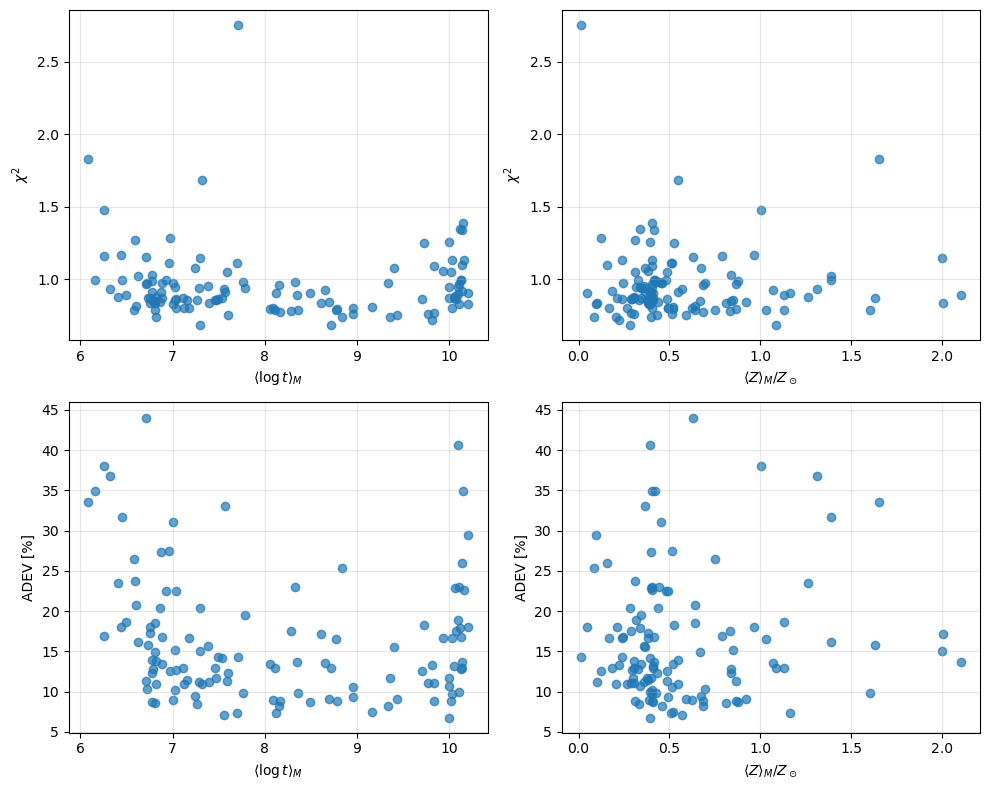

In [453]:
chi2 = np.asarray(sample['CHI2']).astype(float)
adev = np.asarray(sample['ADEV']).astype(float)

age = np.asarray(sample['MEAN_LGTM']).astype(float)
Z   = np.asarray(sample['MEAN_ZM']).astype(float)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0,0].scatter(age, chi2, alpha=0.7)
axes[0,0].set_xlabel(r'$\langle \log t \rangle_M$')
axes[0,0].set_ylabel(r'$\chi^2$')

axes[0,1].scatter(Z, chi2, alpha=0.7)
axes[0,1].set_xlabel(r'$\langle Z \rangle_M / Z_\odot$')
axes[0,1].set_ylabel(r'$\chi^2$')

axes[1,0].scatter(age, adev, alpha=0.7)
axes[1,0].set_xlabel(r'$\langle \log t \rangle_M$')
axes[1,0].set_ylabel('ADEV [%]')

axes[1,1].scatter(Z, adev, alpha=0.7)
axes[1,1].set_xlabel(r'$\langle Z \rangle_M / Z_\odot$')
axes[1,1].set_ylabel('ADEV [%]')

for ax in axes.flat:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

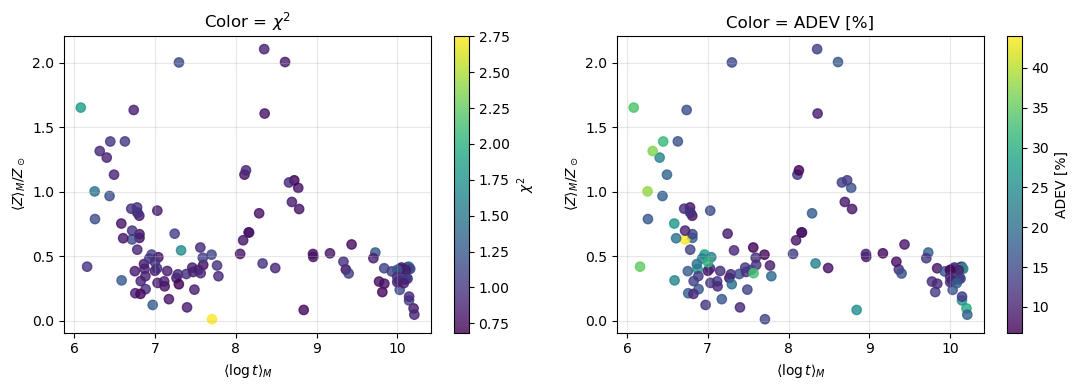

In [454]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sc1 = axes[0].scatter(age, Z, c=chi2, s=45, alpha=0.8)
axes[0].set_xlabel(r'$\langle \log t \rangle_M$')
axes[0].set_ylabel(r'$\langle Z \rangle_M / Z_\odot$')
axes[0].set_title(r'Color = $\chi^2$')
plt.colorbar(sc1, ax=axes[0], label=r'$\chi^2$')

sc2 = axes[1].scatter(age, Z, c=adev, s=45, alpha=0.8)
axes[1].set_xlabel(r'$\langle \log t \rangle_M$')
axes[1].set_ylabel(r'$\langle Z \rangle_M / Z_\odot$')
axes[1].set_title('Color = ADEV [%]')
plt.colorbar(sc2, ax=axes[1], label='ADEV [%]')

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

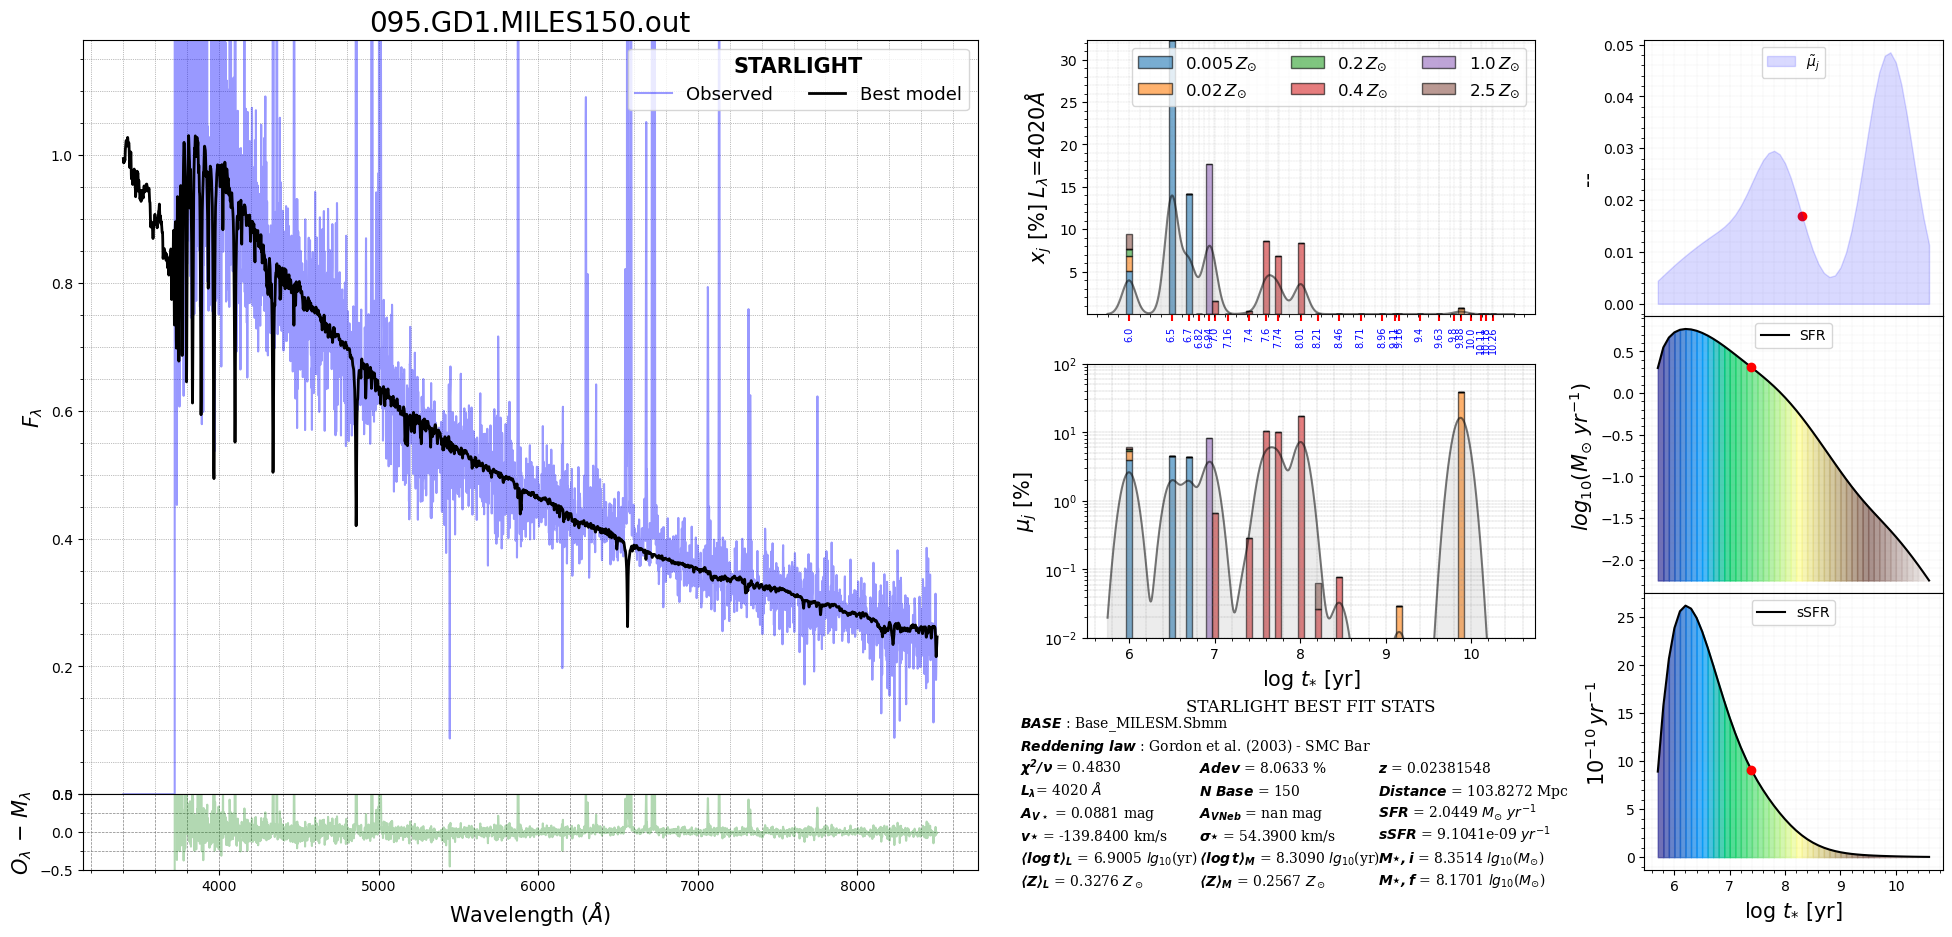

In [14]:
obj = '095'

spec = fs.Starlight(home = os.path.expanduser('~') +'/HIIGalaxies/STARLIGHT/output_4020/',
                    file = f'{obj}.GD1.MILES150.out', 
                    distance = Final_table[Final_table['TAB5_INDEX']>=int(obj)]['Z'][0])

spec.CompositePlot()


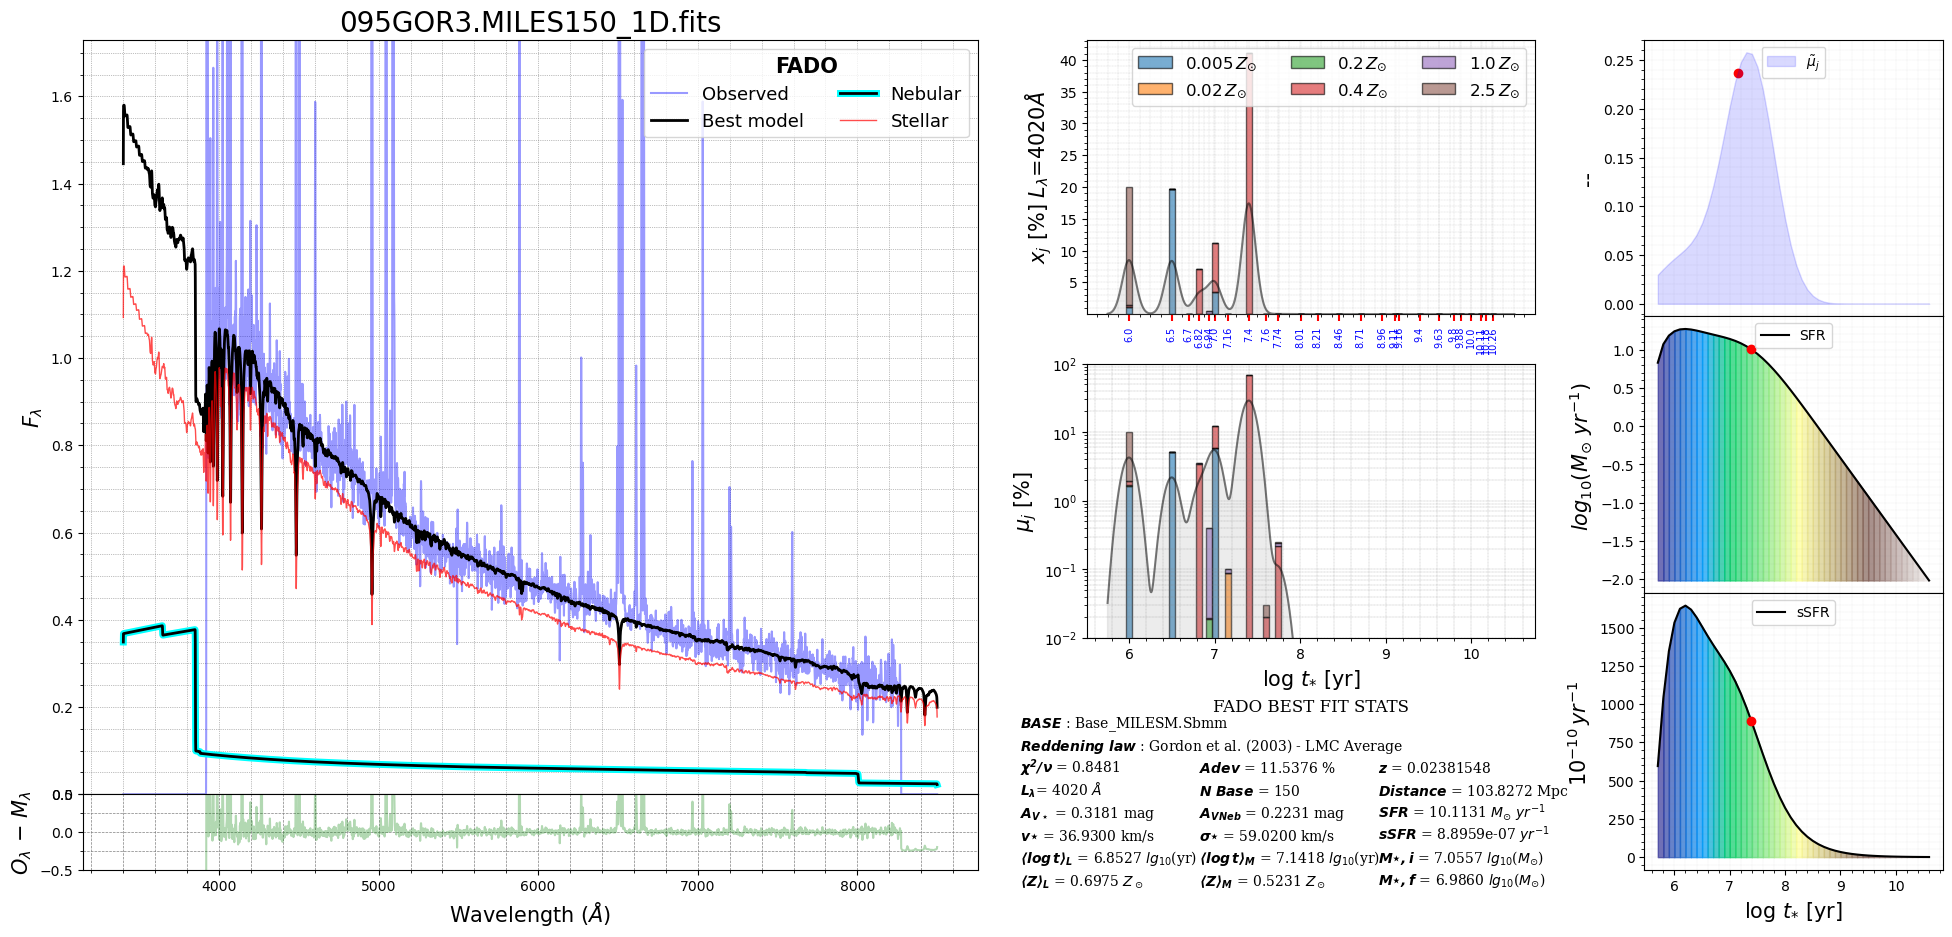

In [15]:
obj = '095'

spec = fs.Fado(home = os.path.expanduser('~') +'/HIIGalaxies/FADO/output_4020/',
               file = f'{obj}GOR3.MILES150_1D.fits', 
               distance = Final_table[Final_table['TAB5_INDEX']>=int(obj)]['Z'][0])

spec.CompositePlot()


In [515]:
t_14 = pd.read_csv('~/HIIGalaxies/Spectral_synthesis/Table6_art2014.csv')

def modelo_lineal(x, m, b):
    return m * x + b

log_x = t_14['log_sigma(Hb)']
log_y = t_14['logL(Hb)']
log_y_err = t_14['logL(Hb)Err']
log_x_err = t_14['log_sigma(Hb)Err']


t_14['r_Hb'] = log_y - modelo_lineal(log_x, 4.824, 33.48)

log_x = t_14['log_sigma([OIII])']
log_y = t_14['logL(Hb)']
log_y_err = t_14['logL(Hb)Err']
log_x_err = t_14['log_sigma([OIII])Err']


t_14['r_[OIII]'] = log_y - modelo_lineal(log_x, 4.824, 33.48)

def OH_to_Z(OH):
    return 10**(OH - 8.69)

t_14['Z_convOH'] = OH_to_Z(t_14['12+logO/H'])


T_art = Table.from_pandas(t_14)


In [516]:
merged = join(sample, T_art, keys='TAB5_INDEX')

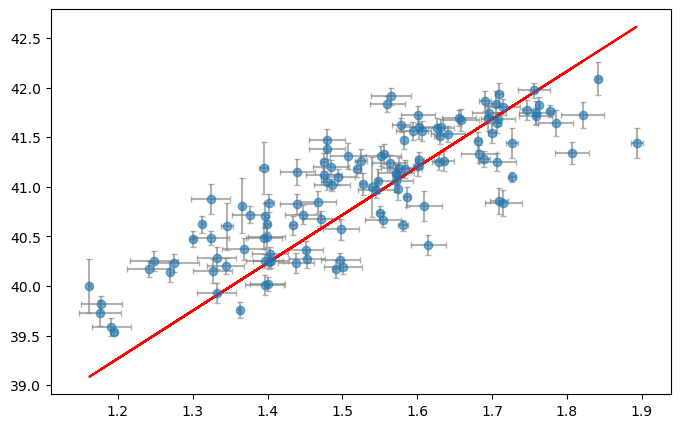

In [495]:

plt.figure(figsize=(8, 5))

plt.errorbar(log_x,log_y,
             yerr = log_y_err,
             xerr= log_x_err,
             fmt='o', 
             ecolor='gray', capsize=2, label='Datos con error', alpha=0.6)
plt.plot(log_x,modelo_lineal(log_x, 4.824, 33.48), 'r-', label='Ajuste Log-Log')


In [520]:
cols = [
    'MEAN_LGTM',        # edad
    'MEAN_ZM',          # metalicidad
    'ADEV',
    'CHI2',
    'LG_MCT',
    'SFR',
    'SSFR',
    'r_[OIII]',
    'logL(Hb)',
    'log_sigma(Hb)',
    'log_sigma([OIII])',
    'logSFR'
]

In [521]:
df = merged.to_pandas()   # o tu tabla ya mergeada

df = df[cols].apply(pd.to_numeric, errors='coerce')
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

In [522]:
corr = df.corr(method='spearman') 

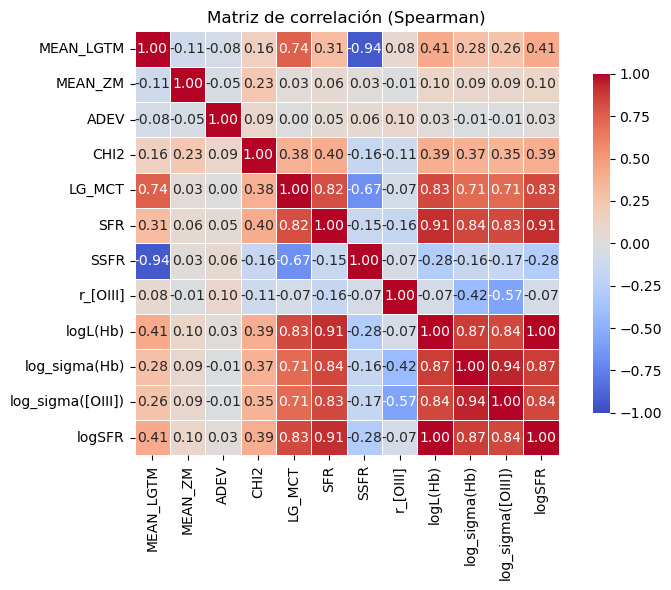

In [523]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title('Matriz de correlación (Spearman)')
plt.tight_layout()
plt.show()

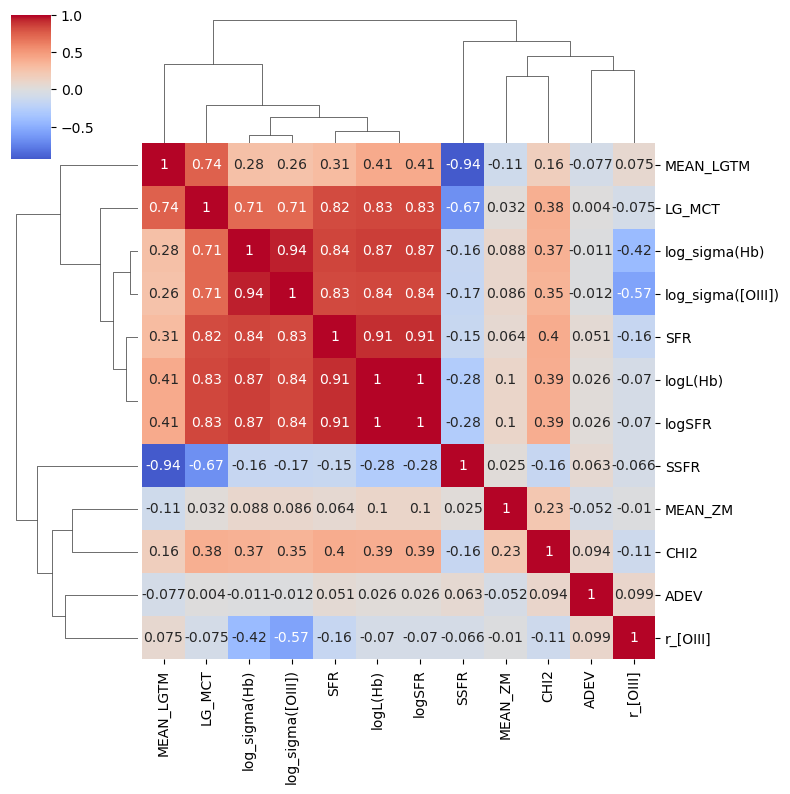

In [524]:
sns.clustermap(
    corr,
    cmap='coolwarm',
    center=0,
    annot=True,
    figsize=(8,8)
)

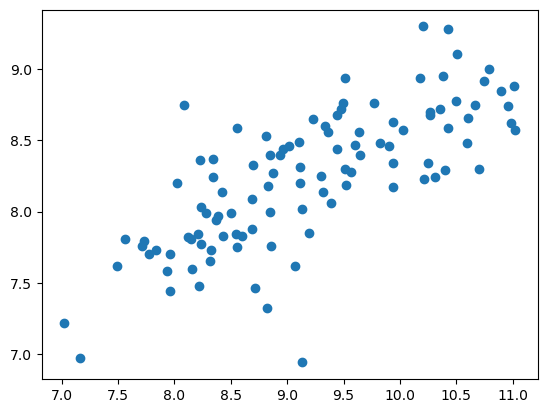

In [519]:
plt.scatter(merged['LG_MCT'],merged['logM_dyn'])

In [505]:
merged.columns

<TableColumns names=('SDSS_PMF','TAB5_INDEX','NED_NAME','PLATE','MJD','FIBERID','RA','DEC','Z','DESI_DR1','SDSS_SNR','STARLIGHT','FADO','LAMBDA_N','CHI2','ADEV','A_V','A_NEB','V_STAR','S_STAR','MEAN_LGTL','MEAN_LGTM','MEAN_ZL','MEAN_ZM','MIT','MCT','LG_MIT','LG_MCT','SFR','SSFR','RED_LAW','BASE_SRC','N_BASE','Flag','z_c','z_cErr','A_v','A_vErr','Q','C_Hb','C_HbErr','log_sigma(Hb)','log_sigma(Hb)Err','log_sigma([OIII])','log_sigma([OIII])Err','logL(Hb)','logL(Hb)Err','12+logO/H','12+logO/HErr','logR_u','logR_uErr','logM_dyn','logM_dynErr','logM_cl','logM_clErr','logM_ion','logM_ionErr','logSFR','logSFRErr','r_Hb','r_[OIII]','Z_convOH')>